In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

In [2]:
df = pd.read_csv(r"E:\my research\algo local\Cardiosense\swat_heart_disease_dataset.csv")

In [3]:
df.drop(columns=['ecg', 'rwma', 'trop', 'angio'], inplace=True)
df.drop_duplicates(inplace=True)

In [4]:
X = df.drop(columns='target')
y = df['target']

In [5]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['age']),

        ('binary_cat',
         OneHotEncoder(drop='first'),
         ['sex', 'diabetes', 'fhist']),

        ('cp_encoder',
         OrdinalEncoder(categories=[[
             'No Angina',
             'Stable Angina',
             'Unstable Angina'
         ]]),
         ['cp']),

        ('bp_encoder',
         OrdinalEncoder(categories=[[
             'Normal',
             'Low',
             'High'
         ]]),
         ['BP']),

        ('activity_encoder',
         OrdinalEncoder(categories=[[
             'High',
             'Moderate',
             'Low'
         ]]),
         ['Physical_Activity'])
    ],
    remainder='passthrough'
)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [7]:
model = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

In [8]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [9]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label='Yes')
recall = recall_score(y_test, y_pred, pos_label='Yes')
f1 = f1_score(y_test, y_pred, pos_label='Yes')

In [10]:
roc_auc = roc_auc_score(
    (y_test == 'Yes').astype(int),
    (y_pred == 'Yes').astype(int)
)

In [11]:
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC AUC   : {roc_auc:.4f}")

Accuracy  : 0.6364
Precision : 0.6522
Recall    : 0.6522
F1 Score  : 0.6522
ROC AUC   : 0.6356


Saved to: DT/confusion_matrix.png


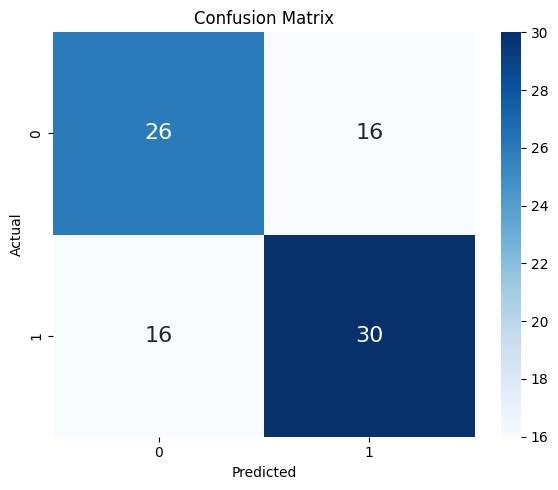

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    annot_kws={"size": 16}
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.savefig("DT/confusion_matrix.png", bbox_inches='tight', dpi=150)
print(f"Saved to: DT/confusion_matrix.png")
plt.show()

In [13]:
metrics = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1 Score': f1,
    'ROC AUC': roc_auc
}

Saved to: DT/decision_tree_performance.png


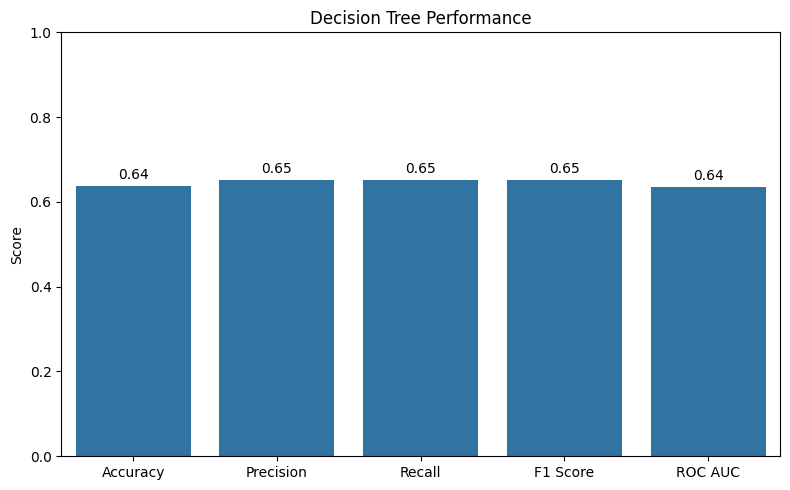

In [14]:

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x=list(metrics.keys()),
    y=list(metrics.values())
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Decision Tree Performance")

plt.tight_layout()
plt.savefig("DT/decision_tree_performance.png", bbox_inches='tight', dpi=150)
print(f"Saved to: DT/decision_tree_performance.png")
plt.show()


In [15]:
#save model using .pkl
import pickle
with open('non_technical_model.pkl', 'wb') as file:
    pickle.dump(model, file)

print("Model saved successfully!")

Model saved successfully!
